# Animated 2D Cloud Lifecycle Simulation (PySDM)
This notebook fixes the spatial axes orientation via transposition, includes a
speed-toggle for fast testing, and generates a fluid animated GIF of the cloud.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Image, display
from tqdm import tqdm

# Enforce stable threading layer for PySDM / Numba
os.environ['NUMBA_THREADING_LAYER'] = 'workqueue'

if 'google.colab' in sys.modules:
    !pip --quiet install open-atmos-jupyter-utils PySDM-examples PySDM matplotlib numpy tqdm pillow
    from open_atmos_jupyter_utils import pip_install_on_colab

from PySDM_examples.Arabas_et_al_2015 import Settings, SpinUp
from PySDM_examples.utils.kinematic_2d import Storage, Simulation
import PySDM.products as PySDM_products
from PySDM import Formulae
from PySDM.physics import si

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.2/172.2 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 339.1/339.1 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 763.0/763.0 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.3/230.3 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.3/55.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 3.5 MB/s eta 0:00:00


## 1. Configuration (Speed Toggle)
Toggle `FAST_TEST_MODE = True` to shrink the grid and super-droplet counts for immediate 2-second testing.

In [2]:
FAST_TEST_MODE = False  # Change to False for the high-fidelity 40-minute simulation

settings = Settings(Formulae())

if FAST_TEST_MODE:
    print("--- RUNNING IN FAST TEST MODE (2-3 seconds runtime) ---")
    settings.n_sd_per_gridbox = 8      # Fewer particles per cell
    settings.grid = (16, 16)            # Smaller grid size
    settings.simulation_time = 15 * si.minute # Shorter virtual timeline
    settings.dt = 10 * si.second        # Larger time steps
else:
    print("--- RUNNING IN FULL PRODUCTION MODE ---")
    settings.n_sd_per_gridbox = 16
    settings.grid = (16, 16)
    settings.simulation_time = 128 * si.minute
    settings.dt = 5 * si.second

# Initialize core objects
tracked_products = [PySDM_products.EffectiveRadius(unit='um')]
storage = Storage()
sim = Simulation(settings, storage, SpinUp)
sim.reinit(products=tracked_products)

product_key = list(sim.particulator.products.keys())[0]

--- RUNNING IN FULL PRODUCTION MODE ---


## 2. Simulation Loop (Frame Collection)
We run the physical simulation and cache every single timestep slice to animate them later.

In [3]:
spatial_frames = []
time_axis_min = []
max_effective_radii = []

for step in tqdm(settings.output_steps, desc="Processing Cloud Physics"):
    sim.particulator.run(step - sim.particulator.n_steps)

    current_time_min = (step * settings.dt) / si.minute
    time_axis_min.append(current_time_min)

    eff_radius_field = sim.particulator.products[product_key].get()
    max_effective_radii.append(np.max(eff_radius_field))

    # FIX: We transpose the grid (.T) right here so Altitude (Z) correctly represents the Y-axis of the image
    spatial_frames.append(np.copy(eff_radius_field.T))

Processing Cloud Physics: 100%|██████████| 129/129 [02:46<00:00,  1.29s/it]


## 3. Compiling and Rendering the Animated GIF
We animate the compiled frames using Matplotlib's `FuncAnimation` and write the result using the `pillow` engine.

Compiling animation frames into a GIF file...
Animation successfully exported to: cloud_simulation.gif


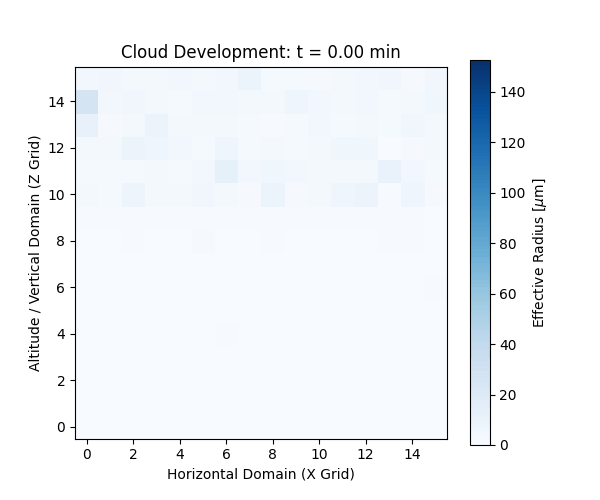

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
global_vmax = max(np.max(frame) for frame in spatial_frames)

# Setup initial structural layout
im = ax.imshow(spatial_frames[0], cmap='Blues', origin='lower', vmin=0, vmax=global_vmax)
cbar = fig.colorbar(im, ax=ax, label=r"Effective Radius [$\mu$m]")
title = ax.set_title("Cloud Development: t = 0.00 min")
ax.set_xlabel("Horizontal Domain (X Grid)")
ax.set_ylabel("Altitude / Vertical Domain (Z Grid)")

def update_animation(frame_idx):
    # Dynamically inject data matrix for current frame index
    im.set_array(spatial_frames[frame_idx])
    title.set_text(f"Cloud Development: t = {time_axis_min[frame_idx]:.2f} min")
    return [im, title]

print("Compiling animation frames into a GIF file...")
ani = animation.FuncAnimation(
    fig,
    update_animation,
    frames=len(spatial_frames),
    interval=100,
    blit=True
)

# Save animation as GIF
gif_filename = 'cloud_simulation.gif'
ani.save(gif_filename, writer='pillow', fps=10)
plt.close(fig) # Prevent duplicate static plotting artifacts

print(f"Animation successfully exported to: {gif_filename}")

# Render GIF inline inside the Jupyter Environment
display(Image(filename=gif_filename))

## 4. Precipitation Kinematics Statistics

[STATS] Rain initiated at 0.00 minutes.


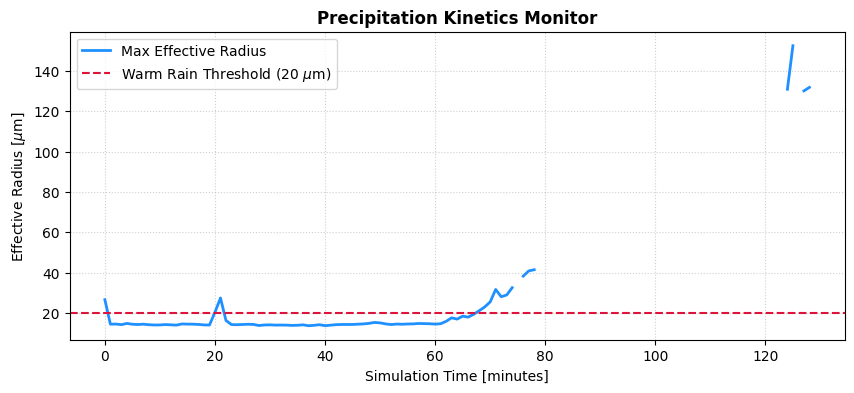

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(time_axis_min, max_effective_radii, color='dodgerblue', linewidth=2, label='Max Effective Radius')
plt.axhline(y=20.0, color='crimson', linestyle='--', label=r'Warm Rain Threshold ($20\ \mu$m)')
plt.xlabel("Simulation Time [minutes]")
plt.ylabel(r"Effective Radius [$\mu$m]")
plt.title("Precipitation Kinetics Monitor", fontsize=12, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

rain_steps = np.where(np.array(max_effective_radii) >= 20.0)[0]
if len(rain_steps) > 0:
    print(f"[STATS] Rain initiated at {time_axis_min[rain_steps[0]]:.2f} minutes.")
else:
    print("[STATS] No rain threshold reached during this execution timeframe.")
plt.show()

<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2991/1589300327.py:44: SyntaxWarning: invalid escape sequence '\m'
  plt.axhline(y=20.0, color='black', linestyle='--', label='Próg deszczu (20 $\mu$m)')
/tmp/ipykernel_2991/1589300327.py:47: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Effective radius [$\mu$m]")
Simulation (factor=10.0): 100%|██████████| 91/91 [01:26<00:00,  1.05it/s]


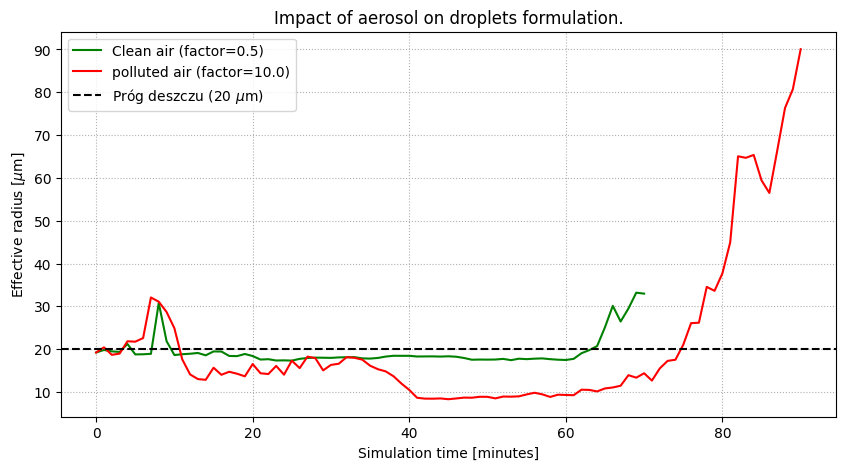

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from PySDM.initialisation import spectra
from PySDM.physics import si
from PySDM_examples.utils.kinematic_2d import Storage, Simulation
from PySDM_examples.Arabas_et_al_2015 import SpinUp

def run_simulation(aerosol_factor):
    settings = Settings(Formulae())

    #modification of aerozol impact - norm_factor consists the amount of particles for cm^3
    settings.mode_1.norm_factor = (60 * aerosol_factor) / si.centimetre**3 / settings.formulae.constants.rho_STP
    settings.mode_2.norm_factor = (40 * aerosol_factor) / si.centimetre**3 / settings.formulae.constants.rho_STP
    settings.spectrum_per_mass_of_dry_air = spectra.Sum((settings.mode_1, settings.mode_2))

    storage = Storage()
    sim = Simulation(settings, storage, SpinUp)
    tracked_products = [PySDM_products.EffectiveRadius(unit='um')]
    sim.reinit(products=tracked_products)
    product_key = list(sim.particulator.products.keys())[0]

    max_effective_radii = []
    time_axis_min = []

    for step in tqdm(settings.output_steps, desc=f"Simulation (factor={aerosol_factor})"):
        sim.particulator.run(step - sim.particulator.n_steps)
        current_time_min = (step * settings.dt) / si.minute
        time_axis_min.append(current_time_min)

        eff_radius_field = sim.particulator.products[product_key].get()
        max_effective_radii.append(np.max(eff_radius_field))

    return time_axis_min, max_effective_radii

# 0.5 - clean air (low concentration of cloud condensation nuclei)
# 10.0 - Polluted air (high concentration of cloud condensation nuclei)
time_clean, radius_clean = run_simulation(0.5)
time_polluted, radius_polluted = run_simulation(10.0)

plt.figure(figsize=(10, 5))
plt.plot(time_clean, radius_clean, label='Clean air (factor=0.5)', color='green')
plt.plot(time_polluted, radius_polluted, label='polluted air (factor=10.0)', color='red')
plt.axhline(y=20.0, color='black', linestyle='--', label='Próg deszczu (20 $\mu$m)')

plt.xlabel("Simulation time [minutes]")
plt.ylabel("Effective radius [$\mu$m]")
plt.title("Impact of aerosol on droplets formulation.")
plt.grid(True, linestyle=':')
plt.legend()
plt.show()